## Image processing - food classifier

### Part I - Baseline Evaluation

Using our own collected data as the input to the classification model. Compare the results versus the results from the Food-101 dataset

First test the model is loaded

c:\anaconda250618\envs\ece253_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model initialized, using device: cuda


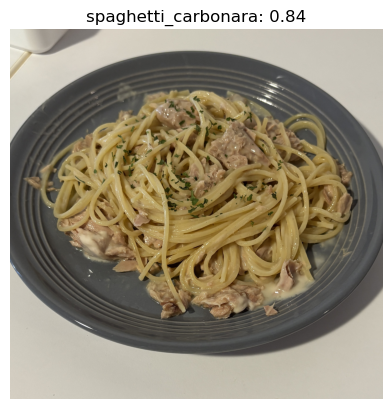

In [1]:
import sys
sys.path.insert(0, './src')
from models.classifier import FoodClassifier
from utils import calculate_metrics
import plot

# Initialize the classification model
model = FoodClassifier()

# Model testing, predict a single image
example_image = './data/example.JPG'
results = model.predict_single(example_image)
plot.single_image(example_image, title=f"{results['label']}: {results['confidence']:.2f}")

Run prediction directly on our collected dataset as the baseline

In [2]:
dataset_path = './data/raw'
results = model.predict_folder(dataset_path)
metrics = calculate_metrics(**results)
print(metrics)

Loaded 44 images from ./data/raw
Predicted 44 images in 4.19s
{'accuracy': 0.7954545454545454, 'f1_score': 0.8537878787878789}


### Part II - Individual Algorithm Evaluation

Process our collected data with the image processing algorithms. Use them as the input to the model

In [3]:
from preprocessing.lowlight import gamma
#from preprocessing.deblurr import f1, f2, f3
from preprocessing.downscaling import downscale_with_aidn, downscale_with_lanczos, downscale_with_l0, pad_to_square_and_downscale_friendly # 導入 downscale_with_l0 和 pad_to_square_and_downscale_friendly
from utils import preprocess_folder # 移除 pad_image_to_square 的導入
import matlab.engine # 新增導入 matlab.engine
import os # 新增導入 os

# AIDN 模型權重路徑 
aidn_weights_path = '.AIDN_repo/LOG/DIV2K/pre-train/AIDN.pth.tar'

# 現有的前處理方法 (gamma)
output_path_gamma = './data/preprocessed_gamma'
for func in [gamma]:
    preprocess_folder(func, input_dir=dataset_path, output_dir=output_path_gamma)
    results = model.predict_folder(dataset_path)
    metrics = calculate_metrics(**results)
    print(f"Metrics for {func.__name__}: {metrics}")

# # 使用 AIDN 進行下採樣 (暫時註釋掉)
# # 假設目標尺寸為 224x224，您可以根據需要調整
# def aidn_downscale_wrapper(image_path):
#     # 首先將圖像填充為正方形
#     padded_img_np = pad_to_square_and_downscale_friendly(image_path) # AIDN 可能需要路徑，所以這裡先假設 image_path 仍然是路徑
#     return downscale_with_aidn(padded_img_np, target_size=(224, 224), model_weights_path=aidn_weights_path)

# output_path_aidn = './data/preprocessed_aidn'
# preprocess_folder(aidn_downscale_wrapper, input_dir=dataset_path, output_dir=output_path_aidn)
# results = model.predict_folder(dataset_path)
# metrics = calculate_metrics(**results)
# print(f"Metrics for AIDN downscaling: {metrics}")

# 使用 Lanczos 進行下採樣
# 目標尺寸為 224x224
def lanczos_downscale_wrapper(image_input_np):
    # 首先將圖像填充為正方形，並使其邊長為 224 的倍數
    padded_img_np = pad_to_square_and_downscale_friendly(image_input_np, target_base_dim=224)
    return downscale_with_lanczos(padded_img_np, target_size=(224, 224))

output_path_lanczos = './data/preprocessed_lanczos'
preprocess_folder(lanczos_downscale_wrapper, input_dir=dataset_path, output_dir=output_path_lanczos)
results = model.predict_folder(dataset_path)
metrics = calculate_metrics(**results)
print(f"Metrics for Lanczos downscaling: {metrics}")

# 使用 L0 梯度最小化進行下採樣
# 目標尺寸為 224x224
def l0_downscale_wrapper(image_input_np, lambda_val: float = 2e-4, kappa_val: float = 2, eng=None):
    if eng is None:
        raise ValueError("MATLAB engine instance (eng) must be provided to l0_downscale_wrapper.")

    current_img_np = image_input_np.copy()
    current_height, current_width = current_img_np.shape[:2]
    max_dim = max(current_height, current_width)
    target_final_dim = 224

    # Case 2: 長邊邊長超過 224 * 16 的情況
    # 重複呼叫 L0 下採樣直到長邊不超過 224 * 16
    while max_dim > target_final_dim * 16:
        print(f"L0 Pre-Downscaling (Coarse): Current max_dim {max_dim} > {target_final_dim * 16}. Applying L0 factor 4.")
        downscale_factor_step = 4  # 使用 4 倍下採樣因子進行粗略縮小
        
        # 在這裡呼叫 downscale_with_l0 時傳入 eng
        current_img_np = downscale_with_l0(current_img_np,
                                            downscaling_factor=downscale_factor_step,
                                            eng=eng, # 傳入 eng
                                            lambda_val=lambda_val, kappa_val=kappa_val)
        current_height, current_width = current_img_np.shape[:2]
        max_dim = max(current_height, current_width)
        print(f"L0 Pre-Downscaling Result: {current_width}x{current_height}")

    # Case 1: 長邊邊長不超過 224 * 16，或已縮小到此範圍。
    # 現在，將最大邊長縮小到 <= 224 但最接近 224 的尺寸。
    if max_dim > target_final_dim:
        print(f"L0 Main Downscaling (Fine): Current max_dim {max_dim} > {target_final_dim}. Finding optimal L0 factor.")
        
        # 找到最小的整數因子 'f' (2-16) 使得 max_dim / f <= target_final_dim
        optimal_downscale_factor = 2
        for f in range(2, 17):
            if max_dim / f <= target_final_dim:
                optimal_downscale_factor = f
                break
        
        print(f"Optimal L0 factor found: {optimal_downscale_factor}.")
        
        # 在這裡呼叫 downscale_with_l0 時傳入 eng
        current_img_np = downscale_with_l0(current_img_np,
                                            downscaling_factor=optimal_downscale_factor,
                                            eng=eng, # 傳入 eng
                                            lambda_val=lambda_val, kappa_val=kappa_val)
        current_height, current_width = current_img_np.shape[:2]
        max_dim = max(current_height, current_width)
        print(f"L0 Main Downscaling Result: {current_width}x{current_height}. (Should be <= {target_final_dim})")
    
    # 最終步驟：填充到 224x224
    # 在此時，current_img_np 的 max_dim 應 <= 224。
    # pad_to_square_and_downscale_friendly 會將其填充為 224x224 的正方形。
    final_processed_img = pad_to_square_and_downscale_friendly(current_img_np, target_base_dim=target_final_dim)
    
    return final_processed_img

output_path_l0 = './data/preprocessed_l0'

# 在呼叫 preprocess_folder 之前啟動 MATLAB 引擎一次
eng = None
try:
    eng = matlab.engine.start_matlab()
    # 將 L-0 downscaling 資料夾添加到 MATLAB 路徑
    project_root = os.getcwd() # 使用 os.getcwd() 獲取當前工作目錄
    l0_downscaling_path = os.path.join(project_root, 'L-0 downscaling')
    eng.addpath(l0_downscaling_path)

    preprocess_folder(lambda img: l0_downscale_wrapper(img, lambda_val=2e-4, kappa_val=2, eng=eng), input_dir=dataset_path, output_dir=output_path_l0)
    results = model.predict_folder(dataset_path)
    metrics = calculate_metrics(**results)
    print(f"Metrics for L0 Downscaling: {metrics}")
finally:
    if eng:
        eng.quit()

# for func in [f1, f2, f3]:
# for func in [d1, d2, d3]:

Loaded 44 images from ./data/raw
Predicted 44 images in 3.65s
Metrics for gamma: {'accuracy': 0.7954545454545454, 'f1_score': 0.8537878787878789}
Loaded 44 images from ./data/raw
Predicted 44 images in 5.02s
Metrics for Lanczos downscaling: {'accuracy': 0.7954545454545454, 'f1_score': 0.8537878787878789}
L0 Main Downscaling (Fine): Current max_dim 1434 > 224. Finding optimal L0 factor.
Optimal L0 factor found: 7.
L0 Main Downscaling Result: 164x205. (Should be <= 224)
L0 Main Downscaling (Fine): Current max_dim 1300 > 224. Finding optimal L0 factor.
Optimal L0 factor found: 6.
L0 Main Downscaling Result: 217x145. (Should be <= 224)
L0 Main Downscaling (Fine): Current max_dim 1514 > 224. Finding optimal L0 factor.
Optimal L0 factor found: 7.
L0 Main Downscaling Result: 217x155. (Should be <= 224)
L0 Pre-Downscaling (Coarse): Current max_dim 5712 > 3584. Applying L0 factor 4.
L0 Pre-Downscaling Result: 804x1428
L0 Main Downscaling (Fine): Current max_dim 1428 > 224. Finding optimal L0 fa

### Part III - Combination Search

### Part IV - Model Fine-Tuning